Artificial Neural Network based on https://selbydavid.com/2018/01/09/neural-network/

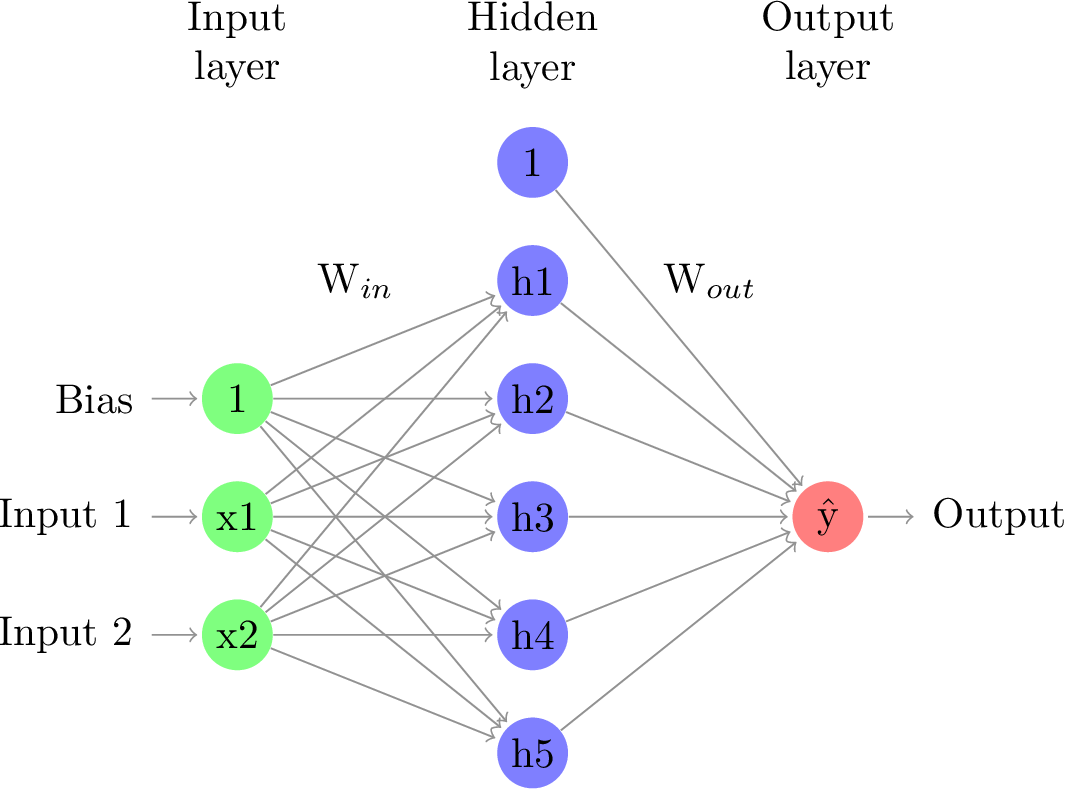

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import random


from IPython.display import Image
Image(filename='./Drawings/draw_neural_network.png') 

# Feedforward:

### The starting point is an $(N \times d)$ matrix $\mathbf{x}$ containing $d$ input features and $N$ samples. 

### First we multiply the input features with the weights in the first hidden layer. We add a bias term, i.e. the "ones" to the input features.

## $$\mathbf{z}_1 = \mathbf{XW}_{in} = \left[ \begin{array}{cc} 1 & \mathbf{x} \end{array} \right] \, \mathbf{W}_{in}$$

### It is important to consider the dimensions of terms. The big advantage of the matrix notation is that we can feed forward the full input feature matrix through the network at once. In contrast to loop over all features. Thus it is important to carefully have an eye on the dimensions of the compartments. The weight matrix $\mathbf{W}_{in}$ is e.g. of dimension $((d+1) \times hidden)$, where $hidden$ is the number of nodes in the hidden layer.

### Following we apply the activation function

## $$\sigma(x)=\frac{1}{1+\exp(-x)}$$

### to the hidden layer:

## $$\mathbf{h}=\sigma(\mathbf{z}_1)$$

### Now we add the bias in the hidden layer

## $$\mathbf{H}=\left[ \begin{array}{cc} 1 & \mathbf{h} \end{array} \right] = \left[ \begin{array}{cc} 1 & \sigma(\mathbf{z}_1) \end{array} \right] = \left[ \begin{array}{cc} 1 & \sigma(\mathbf{XW}_{in}) \end{array} \right]$$

### Next we multiply the hidden layer with another weight matrix

## $$\mathbf{z}_2=\mathbf{HW}_{out}$$

### Since we have only a single node in the output layer, $\mathbf{W}_{out}$ has the dimension $((hidden+1) \times 1)$


### and finally apply again the activation function to obtain the estimations

## $$\hat{\mathbf{y}} = \sigma (\mathbf{z}_2)$$

### Let's code the feed forward process:


In [2]:
def sigmoid(x):
    return 1/(1+np.exp(-x))


def feedforward(x,w1,w2):
    nrows = x.shape[0]
    X = np.column_stack([ np.ones(nrows), x ])
    z1 = X.dot(w1)
    #print(z1)
    h = sigmoid(z1)
    #print(h)
    H = np.column_stack([ np.ones(nrows), h ])
    z2 = H.dot(w2)
    #print(z2)
    out = np.column_stack([ sigmoid(z2), h ])
    #print(out)
    return out

## Backpropagation:

### To adjust the weights we have to minimize a cost function. Thus we use *Gradient Descent* to adjust the weights and to find the minimum of the cost function

### Let's use the mean square error. A more elegant and efficient cost function is the cross entropy, however we will here use the MSE

## $$MSE=\frac{1}{N}\sum_i (\hat y_i - y_i)^2$$

### in vector notation

## $$\mathbf{r}=(\mathbf{\hat {y}} - \mathbf{y})^2$$

### so we have to minimize $\mathbf{r}(\mathbf{W})$ via *Gradient Descent* by iterating

## $$\mathbf{W}_{t+1}=\mathbf{W}_t - \gamma \cdot \nabla \mathbf{r}(\mathbf{W}_t)$$

### where $\mathbf{W}_t$ is the weight matrix at time $t$, $\nabla \mathbf{r}$ is the gradient of $r$ with respect to the weights and $\gamma$ is the *learning rate*

### Now let's calculate the gradient of the output weights:

## $$\frac{\partial \mathbf{r}}{\partial \mathbf{W}_{out}} = \frac{\partial \mathbf{r}}{\partial \hat{\mathbf{y}}} \frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{W}_{out}}$$

### the first term on the right

## $$ \frac{\partial \mathbf{r}}{\partial \hat{\mathbf{y}}} = 2(\hat{\mathbf{y}}-\mathbf{y})$$

### apply again the chain rule to the second term on the right:

## $$\frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{W}_{out}}=\frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{z}_{2}} \frac{\partial \mathbf{z}_2}{\partial {\mathbf{W}_{out}}}$$

### usinf the derivative of the sigmoid 

## $$\frac{\partial \sigma}{\partial x}=\sigma(1-\sigma)$$

### we see that

## $$\frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{z}_{2}}=\hat{\mathbf{y}}(1-\hat{\mathbf{y}})$$

### and

## $$\frac{\partial \mathbf{z}_2}{\partial {\mathbf{W}_{out}}}=\mathbf{H}$$

### putting all together

## $$\frac{\partial \mathbf{r}}{\partial \mathbf{W}_{out}} = 2(\hat{\mathbf{y}}-\mathbf{y}) \cdot \hat{\mathbf{y}}(1-\hat{\mathbf{y}}) \mathbf{H}$$

### We have to take care about the matrix multiplications and the dimensions of the terms. $\hat{\mathbf{y}}$ and $\hat{{y}}$ are column vectors with length $N$ of the number of training samples. $\mathbf{H}$ has dimension $(N \times (hidden+1))$ thus we have to transpose $\mathbf{H}$ and rearange the above formula:

## $$\frac{\partial \mathbf{r}}{\partial \mathbf{W}_{out}} = \mathbf{H}^T \, 2(\hat{\mathbf{y}}-\mathbf{y}) \cdot \hat{\mathbf{y}}(1-\hat{\mathbf{y}}) $$

### The result has exactly dimension $((hidden+1) \times 1)$, similar to the dimension of $\mathbf{W}_{out}$

### Now we have to calculate the gradient according to the input weights:

## $$\frac{\partial \mathbf{r}}{\partial \mathbf{W}_{in}} = \frac{\partial \mathbf{r}}{\partial \hat{\mathbf{y}}} \frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{H}}  \frac{\partial {\mathbf{H}}}{\partial \mathbf{W}_{in}}$$

### we already have the first term and apply the chain rule to the second:

## $$\frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{H}} = \frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{z}_2} \frac{\partial {\mathbf{z}_2}}{\partial \mathbf{H}} $$

### here we again already have the first term and the second is given by:

## $$ \frac{\partial {\mathbf{z}_2}}{\partial \mathbf{H}} = \mathbf{W}_{out}$$

### let's apply the chain rule to the the last term:

## $$ \frac{\partial {\mathbf{H}}}{\partial \mathbf{W}_{in}} = \frac{\partial {\mathbf{H}}}{\partial \mathbf{z}_{1}} \frac{\partial {\mathbf{z}_{1}}}{\partial \mathbf{W}_{in}}$$

## $$ \frac{\partial {\mathbf{H}}}{\partial \mathbf{z}_{1}} = \left[ \begin{array}{cc} 0 & \sigma(z_1)(1-\sigma(z_1)) \end{array} \right] = \left[ \begin{array}{cc} 0 & \mathbf{h}(1-\mathbf{h}) \end{array} \right] = \mathbf{h}(1-\mathbf{h})$$

## $$ \frac{\partial {\mathbf{z}_{1}}}{\partial \mathbf{W}_{in}} = \mathbf{X}$$

### putting it together:

## $$\frac{\partial \mathbf{r}}{\partial \mathbf{W}_{in}} = \left[ 2(\hat{\mathbf{y}}-\mathbf{y}) \cdot \hat{\mathbf{y}}(1-\hat{\mathbf{y}}) \right] \mathbf{W}_{out} \cdot \mathbf{h}(1-\mathbf{h}) \mathbf{X}$$

### again takeing care of the dimension how to apply the matrix operations

## $$\frac{\partial \mathbf{r}}{\partial \mathbf{W}_{in}} = \mathbf{X}^T \left[ \mathbf{h}(1-\mathbf{h}) \cdot \left[ 2(\hat{\mathbf{y}}-\mathbf{y}) \cdot \hat{\mathbf{y}}(1-\hat{\mathbf{y}}) \right] \mathbf{W}_{out}^T \right]  $$

### $\mathbf{y}$ and $\hat{\mathbf{y}}$ are column vectors of length $N$. Thus $\mathbf{W}_{out}$ has to be transposed.  Then the right part has dimension $(N \times hidden)$. 

### $\mathbf{h}$ has also dimension $(N \times hidden)$, thus we have a element wise multiplication. 

### $\mathbf{X}$ has dimension $(N \times (d+1))$, thus $\mathbf{X}$ has to be transposed and the final result has dimension $((d+1) \times hidden)$, which is exactly the dimenion of $\mathbf{W}_{in}$ 


### Now let's code the backprop

In [3]:
def backprop(x,y,y_hat,w1,w2,h,learn_rate):
    nrows = h.shape[0]
    ncols = h.shape[1]
    
    #let's start with dr/dWout
    H = np.column_stack([ np.ones(nrows), h ])
    H = H.T
    res = np.array([y_hat * (1- y_hat)]) * np.array([(y_hat-y)*2])     
    res = res.T
    dw2 = H.dot(res)
    
    #now calculate dr/dWin
    #remove first entry in w2, i.e. the bias weight
    w2r = w2[1:(1+ncols),:]    
    dh = res.dot(w2r.T)     
    X = np.column_stack([ np.ones(nrows), x ])
    dw1 = X.T.dot(h * (1 - h) * dh)
    
    #update weights
    w1 = w1 - learn_rate * dw1
    w2 = w2 - learn_rate * dw2

    out = [w1,w2]
    return out
    

## Create data:

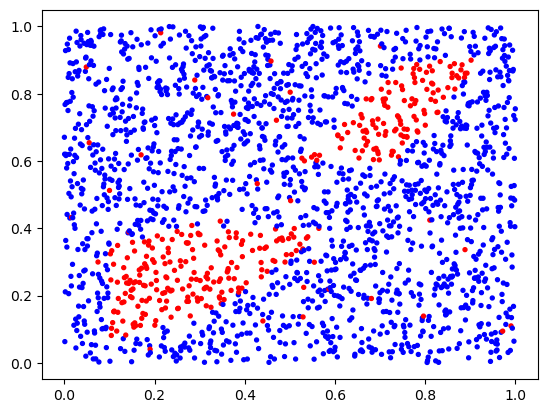

In [10]:
N = 2000
x1 = np.linspace(0.0, 1.0, num=N)
x2 = random.rand(N)
sigma = 0.02
offset = 0.2
w = 1
y = np.zeros(N)
color = []
#create M numbers from 1 to N to be used as noise
M = 40
Noise = np.zeros(N)
epsi = random.randint(1,N,M)
Noise[epsi] = 1
for i in range(N):
    color.append("blue")
    if Noise[i]==1:
        color[i]="red"
        y[i]=1
    if x1[i]>0.1 and x2[i]<0.9:
        if np.square(x2[i]-(w*np.square(x1[i])+offset)) < sigma:
            if  x2[i]<0.4 or x2[i]>0.6:
                y[i]=1
                color[i]="red"


plt.scatter(x1,x2,s=8,color=color)
plt.show()

## Train the network:

Sensitivity tests:
1. hidden=7, noise=400  -> works perfect
2. hidden=3, noise=10   -> underfitting
3. hidden=7, noise=600  -> too noisy

???4. hidden=10, noise=600 -> overfitting noise

In [11]:
def train(X,y,hidden=7,learn_rate=0.01,iterations=20000):
    nrows = X.shape[0]
    d = X.shape[1]
    w1 = random.randn((d+1),hidden)
    w2 = random.randn((hidden+1),1)
    for i in range(iterations):
        ff = feedforward(X,w1,w2)
        y_hat = ff[:,0]
        h = ff[:,[np.arange(1,(hidden+1))]]
        h = h.reshape(nrows,hidden)
        bp = backprop(X,y,y_hat,w1,w2,h,learn_rate)
        w1 = np.array(bp[0])
        w2 = np.array(bp[1])
    out = [y_hat,w1,w2]
    return out

In [12]:
nnet = train(np.column_stack([x1,x2]),y)

out = np.array(nnet[0])
w1 = np.array(nnet[1])
w2 = np.array(nnet[2])


## Apply the network to new "unknown" data

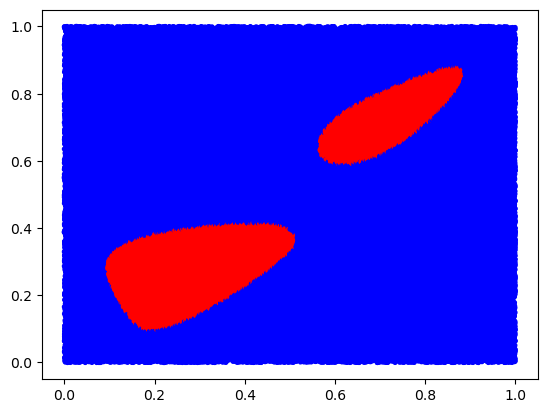

In [13]:
N = 100000
x1 = np.linspace(0.0, 1.0, num=N)
x2 = random.rand(N)
color = []
ff = feedforward(np.column_stack([x1,x2]),w1,w2)
out = np.array(ff[:,0])


for i in range(N):
    if out[i]>0.5:
        color.append("red")
    else:
        color.append("blue")

plt.scatter(x1,x2,s=8,color=color)
plt.show()